# Gurgaon Residential Real Estate Market Analysis

## Objective

The objective of this project is to analyze residential property listings in Gurgaon to identify pricing trends, locality-wise affordability, and the impact of features like BHK, area, builder, and RERA approval on property prices.

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data of gurugram real Estate.csv')
df.head()

,Price,Status,Area,Rate per sqft,Property Type,Locality,Builder Name,RERA Approval,BHK_Count,Society,Company Name,Flat Type
0,10700000,Under Construction,1138,"9,450",2 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,home,Approved by RERA,2,M3M Antalya Hills Phase I,M3M,Apartment
1,14400000,Under Construction,1528,"9,450",3 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,Property In Gurgaon,Approved by RERA,3,M3M Antalya Hills Phase I,M3M,Apartment
2,10700000,Under Construction,1138,"9,450",2 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,properties for sale in Gurgaon,Approved by RERA,2,M3M Antalya Hills Phase I,M3M,Apartment
3,40000000,Ready to move,4500,"8,888",4 BHK Independent Floor,Sector 57,MM India Pvt Ltd,Not approved by RERA,4,Outside Socity,Outside,Plot
4,24000000,Under Construction,1800,"13,333",3 BHK Independent Floor in Anant Raj Estate Plots,Sector 63,MM India Pvt Ltd,Approved by RERA,3,Anant Raj Estate Plots,Anant,Floor


## Data Cleaning

In this step, we cleaned column names, removed duplicates, converted numerical columns, and standardized categorical values.

In [83]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df = df.drop_duplicates()

df['price'] = pd.to_numeric(df['price'].astype(str).str.replace(',', ''), errors='coerce')
df['area'] = pd.to_numeric(df['area'].astype(str).str.replace(' sqft', ''), errors='coerce')
df['rate_per_sqft'] = pd.to_numeric(df['rate_per_sqft'].astype(str).str.replace(',', ''), errors='coerce')

df['status'] = df['status'].str.strip().str.lower()
df['flat_type'] = df['flat_type'].str.strip().str.lower()

df['rera_approval'] = df['rera_approval'].str.strip().str.lower().map({
    'approved by rera': True,
    'not approved by rera': False
})

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14223 entries, 0 to 19514
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          14223 non-null  float64
 1   status         14223 non-null  object 
 2   area           14223 non-null  int64  
 3   rate_per_sqft  14223 non-null  int64  
 4   property_type  14223 non-null  object 
 5   locality       14223 non-null  object 
 6   builder_name   14223 non-null  object 
 7   rera_approval  14223 non-null  bool   
 8   bhk_count      14223 non-null  int64  
 9   society        14223 non-null  object 
 10  company_name   14223 non-null  object 
 11  flat_type      14223 non-null  object 
dtypes: bool(1), float64(1), int64(3), object(7)
memory usage: 1.3+ MB


## Missing Value Analysis

Checking for missing values is a critical step in data cleaning. Missing data can skew analysis and lead to incorrect conclusions.

In [84]:
# Check missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage (%)': missing_pct.round(2)
})

print(missing_df[missing_df['Missing Values'] > 0])
print(f"\nTotal rows after cleaning: {len(df)}")

Empty DataFrame
Columns: [Missing Values, Percentage (%)]
Index: []

Total rows after cleaning: 14223


### Insight

The dataset contains no missing values after the cleaning step.
All 14,223 rows are complete and ready for analysis.

## Feature Engineering

Created a calculated price per sqft column to validate dataset consistency.


In [85]:
df['price_per_sqft_calc'] = df['price'] / df['area']

## Data Validation

To ensure data consistency, the calculated price per sqft was compared with the dataset's provided rate per sqft.

Price per sqft is used as the primary metric for comparison as it standardizes property valuation across different sizes.

In [86]:
df['difference'] = df['rate_per_sqft'] - df['price_per_sqft_calc']
df['difference'].describe()

,difference
count,14223.000000
mean,-9.330150
std,308.807396
min,-20281.416595
25%,-0.333333
50%,0.256055
75%,19.604586
max,392.156863


### Insight

The difference between calculated and provided price per sqft is minimal for most entries, confirming that the dataset is reliable for further analysis.

## Outlier Removal

Before removing outliers, we first examine the spread of key
numerical columns to understand the extent of extreme values.

In [87]:
df[['price', 'area', 'rate_per_sqft']].describe()

,price,area,rate_per_sqft
count,1.422300e+04,14223.000000,14223.000000
mean,3.995377e+07,2621.755959,15296.143992
std,5.755291e+07,11125.298077,18761.002333
min,9.500000e+04,60.000000,100.000000
25%,1.410000e+07,1424.000000,8368.000000
50%,2.620000e+07,2015.000000,12380.000000
75%,4.550000e+07,2840.500000,18500.000000
max,1.226300e+09,958320.000000,310000.000000


In [88]:
# Remove outliers using IQR method on rate_per_sqft
Q1 = df['rate_per_sqft'].quantile(0.25)
Q3 = df['rate_per_sqft'].quantile(0.75)
IQR = Q3 - Q1

df_clean = df[
    (df['rate_per_sqft'] >= Q1 - 1.5 * IQR) &
    (df['rate_per_sqft'] <= Q3 + 1.5 * IQR)
]

print("After outlier removal:", df_clean.shape)
print(f"Rows removed: {len(df) - len(df_clean)}")

After outlier removal: (13747, 14)
Rows removed: 476


### Insight

476 properties were removed as outliers using the IQR method on
rate_per_sqft. These were properties with unrealistically low or
high rates — likely data entry errors or commercial listings.
The remaining 13,747 properties represent a clean, realistic
picture of the Gurgaon residential market.

## Pricing Analysis by Locality

This section identifies the most expensive and affordable localities based on price per sqft. Only includes localities with at least 10 listings.


In [89]:
locality_counts = df_clean.groupby('locality')['rate_per_sqft'].count()
valid_localities = locality_counts[locality_counts >= 10].index

locality_price = df_clean[df_clean['locality'].isin(valid_localities)]\
    .groupby('locality')['rate_per_sqft'].mean()\
    .sort_values(ascending=False)

### Visualization: Top 10 Most Expensive vs Most Affordable Localities

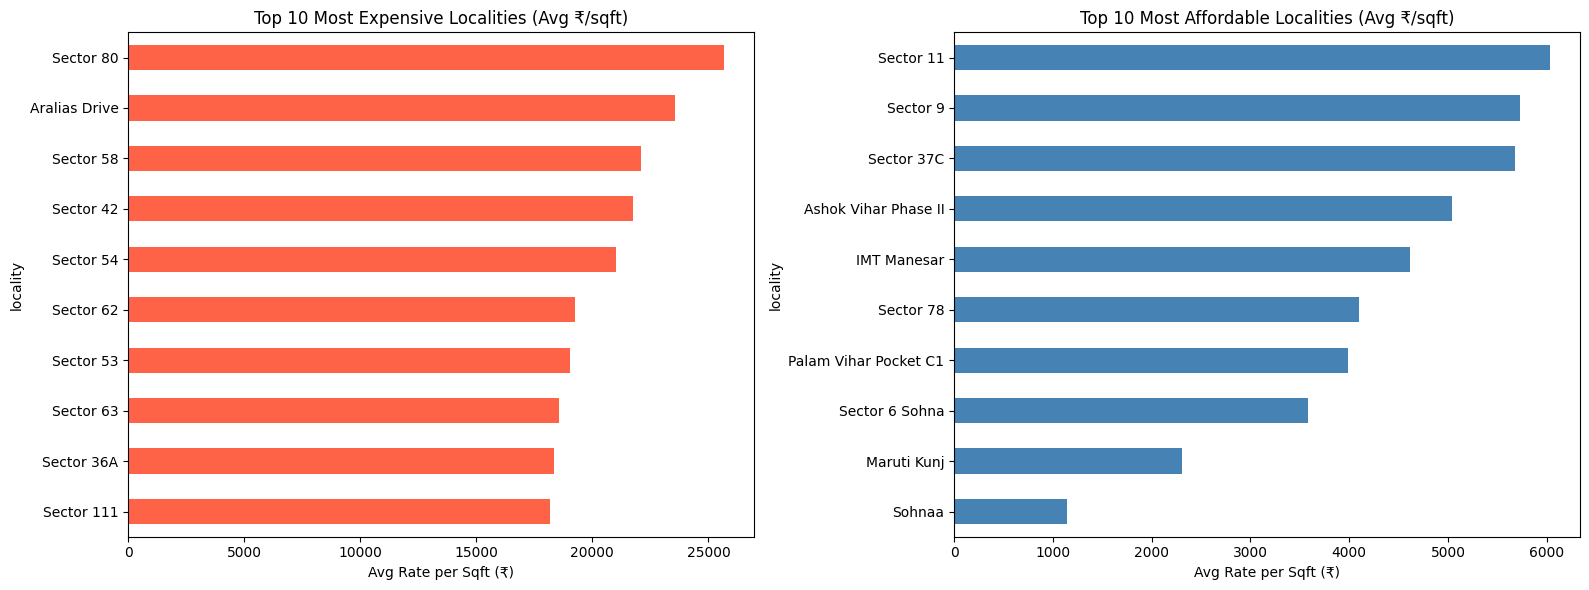

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 most expensive
locality_price.head(10).plot(kind='barh', ax=axes[0], color='tomato')
axes[0].set_title('Top 10 Most Expensive Localities (Avg ₹/sqft)')
axes[0].set_xlabel('Avg Rate per Sqft (₹)')
axes[0].invert_yaxis()

# Top 10 most affordable
locality_price.tail(10).plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 10 Most Affordable Localities (Avg ₹/sqft)')
axes[1].set_xlabel('Avg Rate per Sqft (₹)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### Insight

This analysis is based on the Kaggle dataset,
which doesn't fully cover ultra-premium areas like Golf Course
Road and DLF Phases. So the results reflect what's available
in the data, not the complete Gurgaon market picture.

Within this dataset the story is clear — Sector 80,
Aralias Drive and Sector 58 are the most expensive localities,
averaging above ₹20,000/sqft. These are well-developed sectors
with good connectivity and infrastructure.

On the other end, Sohnaa, Maruti Kunj and Sector 6 Sohna are
the most affordable localities, averaging below ₹3,000/sqft —
mostly located on the outskirts of Gurgaon, farther from
commercial hubs.

The gap between the most expensive and most affordable locality
is nearly 8x — which tells you just how much location matters
in Gurgaon real estate.

## RERA Impact on Pricing


In [91]:
rera_price = df.groupby('rera_approval')['price'].median()

if True in rera_price and False in rera_price:
    diff = (rera_price[True] - rera_price[False]) / rera_price[False] * 100
    print(f"RERA-approved properties are {diff:.2f}% more expensive")
else:
    print("RERA categories missing")

RERA-approved properties are 5.04% more expensive


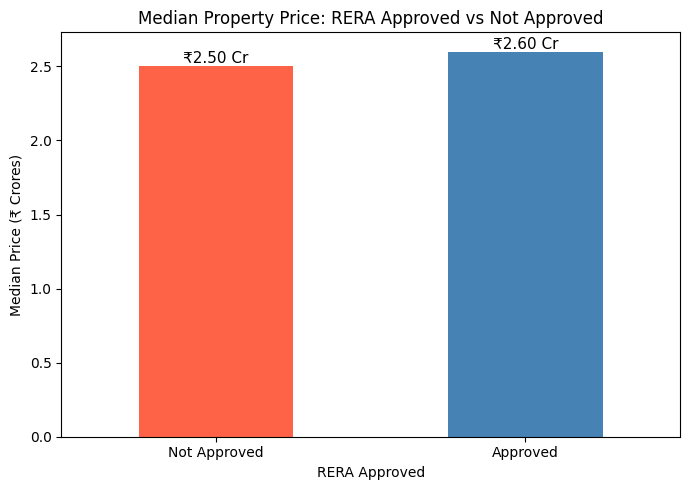

In [92]:
rera_price = df_clean.groupby('rera_approval')['price'].median() / 1e7

ax = rera_price.plot(kind='bar', color=['tomato', 'steelblue'], figsize=(7, 5))
ax.set_title('Median Property Price: RERA Approved vs Not Approved')
ax.set_xlabel('RERA Approved')
ax.set_ylabel('Median Price (₹ Crores)')
ax.set_xticklabels(['Not Approved', 'Approved'], rotation=0)

for p in ax.patches:
    ax.annotate(f'₹{p.get_height():.2f} Cr',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

### Insight

RERA-approved properties have a median price of ₹2.60 Cr compared
to ₹2.50 Cr for non-approved properties — a premium of 5.04%.

This premium reflects the higher trust and transparency that RERA
approval brings to buyers. RERA-approved projects are legally bound
to deliver on time, maintain quality standards, and provide full
financial transparency — making buyers willing to pay more for
that security.

For investors, this suggests that RERA approval is not just a
legal formality — it is a genuine value driver in the Gurgaon
real estate market.

## Area vs Price Analysis

This section analyzes how property area impacts overall property price.

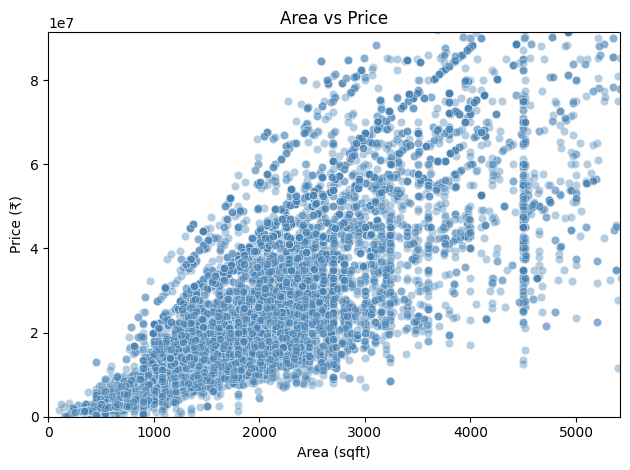

In [93]:
sns.scatterplot(x='area', y='price', data=df_clean, alpha=0.4, color='steelblue')
plt.title('Area vs Price')
plt.xlabel('Area (sqft)')
plt.ylabel('Price (₹)')

# Focus view on 95th percentile to avoid chart being squished
plt.xlim(0, df_clean['area'].quantile(0.95))
plt.ylim(0, df_clean['price'].quantile(0.95))

plt.tight_layout()
plt.show()

### Insight

The scatter plot reveals a clear positive relationship between
property area and price — larger properties generally command
higher prices. Most residential properties in Gurgaon fall
between 1,000 to 4,000 sqft, with prices ranging from ₹50 lakh
to ₹8 crore.

However, the wide vertical spread of dots at any given area size
shows that area alone does not determine price. Two properties of
the same size can have very different prices — confirming that
locality and rate per sqft are stronger pricing factors than
size alone.

## Correlation Analysis

This section evaluates the relationship between numerical variables to identify key drivers of property pricing.

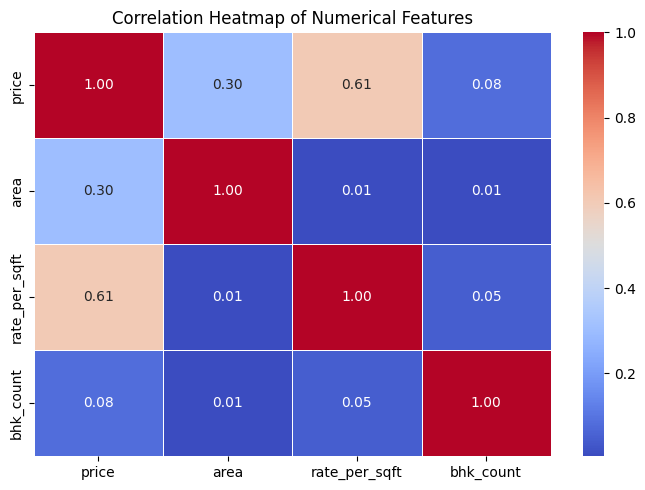

In [94]:
corr = df_clean[['price', 'area', 'rate_per_sqft', 'bhk_count']].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

### Insight

The heatmap reveals three key findings:

1. rate_per_sqft has the strongest correlation with price (0.61) —
   confirming that location-driven pricing is the biggest factor
   in determining property value in Gurgaon.

2. area has a moderate correlation with price (0.30) — larger
   properties cost more overall, but size alone is not the
   primary driver of price.

3. bhk_count has almost no correlation with price (0.08) or
   rate_per_sqft (0.05) — meaning the number of bedrooms alone
   does not significantly impact pricing. A 3 BHK in Sector 42
   can cost far more than a 4 BHK in Sohna.

Overall, locality and rate per sqft are far stronger indicators
of property value than size or bedroom count.

## Key Takeaways

- 476 outlier properties were removed using the IQR method to
  ensure analysis reflects the realistic Gurgaon market
- Location is the strongest driver of property pricing —
  rate_per_sqft has a 0.61 correlation with price
- Sector 80, Aralias Drive and Sector 58 are the most expensive
  localities averaging above ₹20,000/sqft
- Sohnaa, Maruti Kunj and Sector 6 Sohna are the most affordable
  localities averaging below ₹3,000/sqft
- RERA-approved properties command a 5.04% price premium over
  non-approved properties
- Larger properties cost more overall, but area has only a
  moderate correlation (0.30) with price
- BHK count has almost no impact on pricing (0.08 correlation) —
  location matters far more than bedroom count

## Conclusion

The Gurgaon residential real estate market shows strong and clear
patterns. Location is by far the most powerful pricing factor —
a property in Sector 80 can cost 8x more per sqft than one in
Sohnaa. RERA approval adds a measurable 5.04% price premium,
reflecting buyer trust in regulated projects.

For buyers, rate per sqft and locality should be the primary
evaluation metrics — not total price or bedroom count. For
investors, RERA-approved properties in well-connected localities
offer the best combination of value and security.